# Árbol de decisión - Titanic

Objetivo: entrenar un clasificador de árbol de decisión y evaluar en entrenamiento y prueba.

## 1) Librerias

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn

In [86]:
# Datos
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report, roc_auc_score, roc_curve

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn import set_config
set_config(transform_output = "pandas")

## 2) Cargar datos

In [87]:
# Esto se debe cambiar por la ruta correcta del dataset
# Leer archivo
data = pd.read_csv("titanic.csv")


In [88]:
# Vista rapida
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [89]:
# Tipos de columnas
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 3) Preparar datos

In [90]:
# NOTA: Deben cambiar esto por los que correspondan a su dataset.

variables_a_descartar = ["PassengerId", "Name", "Cabin", "Ticket"]

variables_categoricas = ["Sex", "Embarked"]
variables_numericas = ["Pclass", "SibSp", "Parch", "Fare", "Age"]
variables_ordinales = ["Pclass"]  # Ejemplo de variable ordinal (es como una categorica pero tiene orden), ajusten según su dataset

 # Descartamos variables que no deberian aportar informacion, o que
 # al contrario, pueden aportar información pero tienen muchos valores únicos,
 # lo que dificulta su uso directo en modelos de machine learning.
variable_dependiente = "Survived"

In [91]:
for var in variables_categoricas:
    data[var] = data[var].astype("category")

In [92]:
# Deben elegir uno de estos caminos

# Eliminar faltantes clave (si es que hay)
# datos_modelo = titanic.dropna(subset=["Age", "Embarked"])

# Imputar faltantes (si es que hay)
# titanic["Age"].fillna(titanic["Age"].median(), inplace=True)

In [93]:
# Resumen
data.describe(include="all")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [94]:
X = data.drop([variable_dependiente] + variables_a_descartar, axis=1)
y = data[variable_dependiente]

In [95]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [96]:
# Puede que su variable dependiente no esté en formato numérico, lo que es necesario para el modelo de árbol de decisión. 
# En ese caso, deben convertirla a numérica. Por ejemplo, si "Survived" es categórica, pueden hacer lo siguiente:
# Ajusta según los valores reales de tu variable dependiente
# y = y.map({"No": 0, "Yes": 1})  

## 4) Separar entrenamiento y prueba (80/20)

In [97]:
random_state = 42 # Esta semilla asegura que los resultados sean reproducibles

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

## 5) Variables para árbol de decisión (numéricas + codificación simple)

In [107]:
# Este modelo es un clasificador de árbol de decisión.
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
# Hiperparametros interesantes para explorar:
# - max_depth: Profundidad máxima del árbol.
# - min_samples_split: Número mínimo de muestras requeridas para dividir un nodo.
# - min_samples_leaf: Número mínimo de muestras requeridas en una hoja.
# Cualquier cambio en estos hiperparámetros puede afectar significativamente el rendimiento del modelo,
# por lo que es importante experimentar con ellos para encontrar la mejor configuración para su dataset específico.
modelo = DecisionTreeClassifier(max_depth=2, random_state=random_state)

# 1) Este es un ejemplo de pipeline que incluye imputación de valores faltantes, 
# escalado de variables numéricas y codificación de variables categóricas.
#
# 2) Los pipelines permiten encadenar varios pasos de preprocesamiento y modelado, 
# lo que facilita la gestión del flujo de trabajo y reduce el riesgo de errores.

# 3) Se pueden combinar con ColumnTransformers para aplicar diferentes transformaciones a
# diferentes tipos de variables (numéricas, categóricas, ordinales, etc.).
pipeline = Pipeline([
    ("preprocesamiento", ColumnTransformer([
        ("numerico", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),  # Imputar valores faltantes
            ("scaler", StandardScaler()),
        ]), variables_numericas),
        ("categorico", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),  # Imputar valores faltantes
            ("encoder", OneHotEncoder(drop="first", sparse_output=False)) # Se bota la primera categoría para evitar multicolinealidad
        ]), variables_categoricas)
    ])),
    ("modelo", modelo)
])

## 6) Entrenar y predecir

In [108]:
# Ajustar modelo
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerico', ...), ('categorico', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

[Text(0.5, 0.8333333333333334, 'categorico__Sex_male <= 0.5\ngini = 0.469\nsamples = 712\nvalue = [444, 268]\nclass = No'),
 Text(0.25, 0.5, 'numerico__Pclass <= 0.206\ngini = 0.386\nsamples = 245\nvalue = [64, 181]\nclass = Yes'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.074\nsamples = 130\nvalue = [5, 125]\nclass = Yes'),
 Text(0.375, 0.16666666666666666, 'gini = 0.5\nsamples = 115\nvalue = [59.0, 56.0]\nclass = No'),
 Text(0.75, 0.5, 'numerico__Age <= -1.771\ngini = 0.303\nsamples = 467\nvalue = [380, 87]\nclass = No'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.434\nsamples = 22\nvalue = [7.0, 15.0]\nclass = Yes'),
 Text(0.875, 0.16666666666666666, 'gini = 0.271\nsamples = 445\nvalue = [373, 72]\nclass = No')]

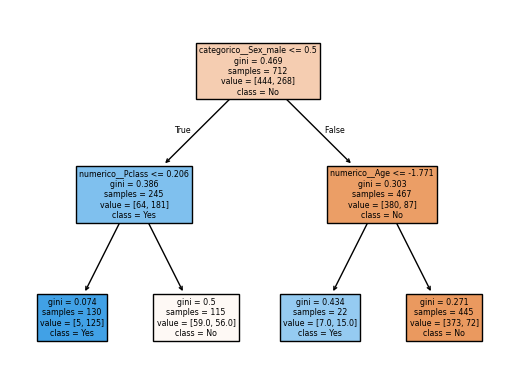

In [109]:
feature_names = pipeline.named_steps["preprocesamiento"].get_feature_names_out()
plot_tree(modelo, feature_names=feature_names,class_names=["No", "Yes"], filled=True)

In [110]:
umbral = 0.5 # Este umbral puede ajustarse según las necesidades del problema, pero 0.5 es un punto de partida común.
umbral = y_train.mean()  # Por ejemplo, usar la media de la variable dependiente como umbral

In [77]:
# Prediccion entrenamiento
y_train_pred = pipeline.predict_proba(X_train)[:, 1]  # Probabilidad de la clase positiva
y_train_pred_class = y_train_pred >= umbral  # Convertir a clase binaria usando un umbral basado en la media de la variable dependiente


In [78]:
# Prediccion prueba
y_test_pred = pipeline.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva
y_test_pred_class = y_test_pred >= umbral  # Convertir a clase binaria usando un umbral basado en la media de la variable dependiente


## 7) Evaluacion

In [79]:
# Matriz de confusion entrenamiento
cm = confusion_matrix(y_test, y_test_pred_class)
pd.DataFrame(cm, index=['Real_0', 'Real_1'], columns=['Pred_0', 'Pred_1'])


,Pred_0,Pred_1
Real_0,87,18
Real_1,21,53


In [80]:
# Reporte de clasificacion
print(classification_report(y_test, y_test_pred_class, digits=4, zero_division=0))


              precision    recall  f1-score   support

           0     0.8056    0.8286    0.8169       105
           1     0.7465    0.7162    0.7310        74

    accuracy                         0.7821       179
   macro avg     0.7760    0.7724    0.7740       179
weighted avg     0.7811    0.7821    0.7814       179



In [81]:
# Matriz de confusion prueba
cm = confusion_matrix(y_test, y_test_pred_class)
pd.DataFrame(cm, index=['Real_0', 'Real_1'], columns=['Pred_0', 'Pred_1'])


,Pred_0,Pred_1
Real_0,87,18
Real_1,21,53


In [82]:
# Reporte de clasificacion
print(classification_report(y_test, y_test_pred_class, digits=4, zero_division=0))


              precision    recall  f1-score   support

           0     0.8056    0.8286    0.8169       105
           1     0.7465    0.7162    0.7310        74

    accuracy                         0.7821       179
   macro avg     0.7760    0.7724    0.7740       179
weighted avg     0.7811    0.7821    0.7814       179



In [83]:
# Metricas respecto a clase 1 (la clase positiva)
train_accuracy = accuracy_score(y_train, y_train_pred_class)
test_accuracy = accuracy_score(y_test, y_test_pred_class)
train_recall = recall_score(y_train, y_train_pred_class, zero_division=0)
test_recall = recall_score(y_test, y_test_pred_class, zero_division=0)
train_precision = precision_score(y_train, y_train_pred_class, zero_division=0)
test_precision = precision_score(y_test, y_test_pred_class, zero_division=0)
train_auroc = roc_auc_score(y_train, y_train_pred)
test_auroc = roc_auc_score(y_test, y_test_pred)

print (f"Accuracy entrenamiento: {train_accuracy:.4f}")
print (f"Accuracy prueba: {test_accuracy:.4f}")
print (f"Recall entrenamiento: {train_recall:.4f}")
print (f"Recall prueba: {test_recall:.4f}")
print (f"Precision entrenamiento: {train_precision:.4f}")
print (f"Precision prueba: {test_precision:.4f}")
print (f"AUROC entrenamiento: {train_auroc:.4f}")
print (f"AUROC prueba: {test_auroc:.4f}")

Accuracy entrenamiento: 0.7992
Accuracy prueba: 0.7821
Recall entrenamiento: 0.7313
Recall prueba: 0.7162
Precision entrenamiento: 0.7341
Precision prueba: 0.7465
AUROC entrenamiento: 0.8210
AUROC prueba: 0.8003


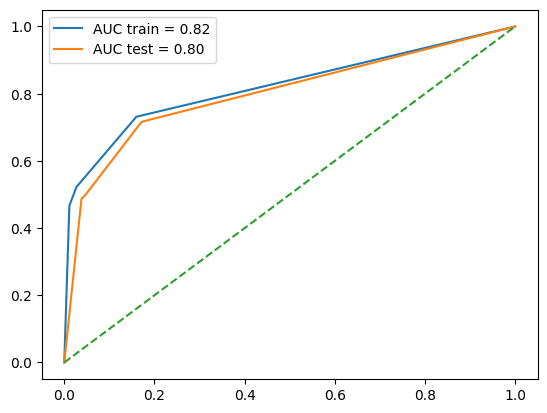

In [84]:
train_roc_fpr, train_roc_tpr, train_roc_thresholds = roc_curve(y_train, y_train_pred)
test_roc_fpr, test_roc_tpr, test_roc_thresholds = roc_curve(y_test, y_test_pred)

plt.figure()
sns.lineplot(x=train_roc_fpr, y=train_roc_tpr, label=f"AUC train = {train_auroc:.2f}")
sns.lineplot(x=test_roc_fpr, y=test_roc_tpr, label=f"AUC test = {test_auroc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier